# Librerías

In [1]:
import os
import urllib.request
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Carga de datos

**Resolución del `FileNotFoundError` e Ingesta de Datos**

El cuaderno original presenta un error debido a la ausencia local de los archivos `.h5` que contienen el dataset "Cat vs Non-Cat". Para solucionar esto de manera automatizada, descargaremos los archivos desde los repositorios remotos proporcionados antes de intentar leerlos con la librería `h5py`.

In [2]:
url_entrenamiento = "https://github.com/rvarun7777/Deep_Learning/raw/master/Neural%20Networks%20and%20Deep%20Learning/Week%202/Logistic%20Regression%20as%20a%20Neural%20Network/datasets/train_catvnoncat.h5"
url_prueba = "https://github.com/rvarun7777/Deep_Learning/raw/master/Neural%20Networks%20and%20Deep%20Learning/Week%202/Logistic%20Regression%20as%20a%20Neural%20Network/datasets/test_catvnoncat.h5"

if not os.path.exists("train_catvnoncat.h5"):
    urllib.request.urlretrieve(url_entrenamiento, "train_catvnoncat.h5")
if not os.path.exists("test_catvnoncat.h5"):
    urllib.request.urlretrieve(url_prueba, "test_catvnoncat.h5")

train_dataset = h5py.File("train_catvnoncat.h5", "r")
test_dataset = h5py.File("test_catvnoncat.h5", "r")

xtrain_classes = np.array(train_dataset["list_classes"][:])
xtrain = np.array(train_dataset["train_set_x"][:])
train_label = np.array(train_dataset["train_set_y"][:])

xtest_classes = np.array(test_dataset["list_classes"][:])
xtest = np.array(test_dataset["test_set_x"][:])
test_label = np.array(test_dataset["test_set_y"][:])

print(f"Dimensiones originales de entrenamiento (xtrain): {xtrain.shape}")
print(f"Dimensiones originales de prueba (xtest): {xtest.shape}")

Dimensiones originales de entrenamiento (xtrain): (209, 64, 64, 3)
Dimensiones originales de prueba (xtest): (50, 64, 64, 3)


**Preprocesamiento: Aplanado y Normalización**

Las dimensiones originales de las imágenes son tridimensionales $(m, 64, 64, 3)$, representando la cantidad de muestras, altura, anchura y canales de color RGB.

Para que las imágenes puedan ser procesadas mediante multiplicaciones matriciales en una red neuronal, es necesario transformarlas a vectores unidimensionales. El proceso de **aplanado** (*flattening*) redimensiona las matrices para que cada imagen sea una única columna vectorial de dimensión $(64 \times 64 \times 3 = 12288)$. La matriz final de entrada tendrá dimensiones $(n_x, m)$.

Adicionalmente, se aplica una **normalización** dividiendo los valores de los píxeles entre 255. Esto garantiza que todas las características se encuentren en el rango $[0, 1]$, mejorando la estabilidad numérica y la velocidad de convergencia del gradiente descendente.

Dimensión de características de entrada (n_x): 12288
Dimensiones finales de xtrain_ (Aplanado y normalizado): (12288, 209)
Dimensiones finales de train_label: (1, 209)


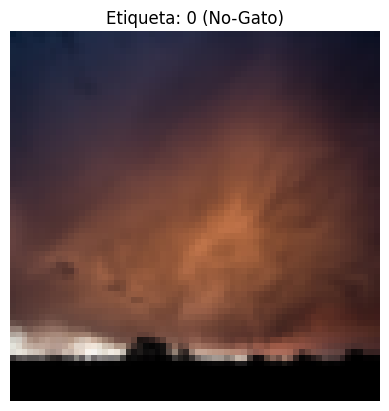

In [3]:
m_train = xtrain.shape[0]
m_test = xtest.shape[0]
num_px = xtrain.shape[1]

xtrain_flatten = xtrain.reshape(m_train, -1).T
xtest_flatten = xtest.reshape(m_test, -1).T

xtrain_ = xtrain_flatten / 255.0
xtest_ = xtest_flatten / 255.0

train_label = train_label.reshape(1, m_train)
test_label = test_label.reshape(1, m_test)

print(f"Dimensión de características de entrada (n_x): {xtrain_.shape[0]}")
print(f"Dimensiones finales de xtrain_ (Aplanado y normalizado): {xtrain_.shape}")
print(f"Dimensiones finales de train_label: {train_label.shape}")

plt.imshow(xtrain[208])
plt.axis('off')
plt.title(f"Etiqueta: {train_label[0, 208]} (No-Gato)" if train_label[0, 208] == 0 else f"Etiqueta: {train_label[0, 208]} (Gato)")
plt.show()

# Parte 2: Red Neuronal

> **1. Construir un clase que permita definir una red neuronal con la topología deseada y la función de activación para cada capa, para ello deberá construir una funcion Topology con el número de capas de la red neuronal :**

### Topología e Inicialización Orientada a Objetos

En una red neuronal, la propagación de información de una capa $l-1$ a una capa $l$ requiere dos operaciones fundamentales:
1. **Combinación lineal ($Z^{[l]}$):** $Z^{[l]} = \Theta^{[l]} A^{[l-1]} + b^{[l]}$
2. **Activación ($A^{[l]}$):** $A^{[l]} = f(Z^{[l]})$

Para que la red pueda "aprender", los parámetros $\Theta$ y $b$ no pueden empezar en cero simétricamente (debido al problema de la simetría de pesos). Se inicializan de manera aleatoria, multiplicados por un factor para mantenerlos en un rango pequeño (como entre -1 y 1) y evitar que funciones de activación como la Sigmoide se saturen en los extremos.

Adicionalmente, se define una función de soporte matemática `act_function` que devuelve tanto la función de activación $f(x)$ como su derivada $f'(x)$, elementos críticos para la fase posterior de retropropagación (*Backward Propagation*).

> - **a. Cada unas de las capas deberá tener los parámetros de inicialización de manera aleatoria:**
> **La matriz de parametros para cada capa debera tener:**
> $\dim(\vec{b}^{[l]}) = n^{[l]}$
> $\dim(\vec{\Theta}^{[l]}) = n^{[l]} \times n^{[l-1]}$
> **Lo anteriores parametros deberán estar en el constructor de la clase.**

> - **b. Construya un metodo llamado output cuya salida serán los valores de Z y A**
> $\dim(\vec{A}^{[l]}) = n^{[l-1]} \times m$
> $\dim(\vec{Z}^{[l]}) = n^{[l]} \times m$

In [4]:
def act_function(x, activation):
    """
    Retorna la función de activación y su derivada matemática.
    """
    if activation == "sigmoid":
        f = lambda z: 1 / (1 + np.exp(-z))
        fp = lambda z: f(z) * (1 - f(z))
        return f, fp
    elif activation == "tanh":
        f = lambda z: np.tanh(z)
        fp = lambda z: 1 - np.tanh(z)**2
        return f, fp
    else:
        # Fallback lineal
        f = lambda z: z
        fp = lambda z: np.ones_like(z)
        return f, fp

class layer_nn():
    def __init__(self, act_fun, nlayer_present, nlayer_before):
        """
        Constructor corregido:
        1. Quitamos el seed interno para que las capas no sean idénticas.
        2. Escalamos los pesos para que la información fluya mejor.
        """
        # Inicialización de He: ayuda a que el gradiente no se desvanezca
        escritorio = np.sqrt(2.0 / nlayer_before)
        self.theta = np.random.randn(nlayer_present, nlayer_before) * escritorio

        # Sesgos inicializados en cero
        self.B = np.zeros((nlayer_present, 1))
        self.act_fun = act_fun

    def output(self, A_prev):
        """Calcula la combinación lineal y la activación"""
        self.Z = self.theta @ A_prev + self.B
        f, _ = act_function(self.Z, self.act_fun)
        self.A = f(self.Z)
        return self.Z, self.A

In [5]:
# --- PRUEBA ESTRUCTURAL ---
# Definición de topología:[Input (12288), Oculta 1 (10), Oculta 2 (3), Output (1)]
topology = [xtrain_.shape[0], 10, 3, 1]

# Instanciamos una capa de prueba (Capa 1: 12288 -> 10 neuronas)
l1 = layer_nn("sigmoid", topology[1], topology[0])

# Simulamos el forward pass para esa única capa
Z1, A1 = l1.output(xtrain_)

print(f"Dimensiones de Theta L1: {l1.theta.shape}")
print(f"Dimensiones de A_prev (X): {xtrain_.shape}")
print(f"Dimensiones de Z1: {Z1.shape}")
print(f"Dimensiones de A1: {A1.shape}")

Dimensiones de Theta L1: (10, 12288)
Dimensiones de A_prev (X): (12288, 209)
Dimensiones de Z1: (10, 209)
Dimensiones de A1: (10, 209)


> **2. Construir un generalizacion de la red, en el que entrada el valor inicial y la red neuronal completa arroje la salida y la actualizacion de la red con los parametros deseados:**
>
> `A, nn = forward_pass(A0, nn_red)`

**Generalización del Forward Pass**

Matemáticamente, la red neuronal opera mediante una composición de funciones. Si definimos la entrada inicial como la capa cero ($A^{[0]} = X$), la propagación hacia adelante iterará sobre cada capa $l$ calculando:

$$Z^{[l]} = \Theta^{[l]}A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = f(Z^{[l]})$$

La salida de una capa se convierte directamente en la entrada de la siguiente. Al finalizar el recorrido sobre las $L$ capas de la red, obtenemos $A^{[L]}$, que es nuestro vector de predicciones finales ($\hat{y}$).

Implementaremos una función para inicializar la lista de capas (`nn_red`) basándonos en una topología dada, y posteriormente la función `forward_pass` que ejecutará las operaciones matriciales secuenciales.

In [6]:
def create_network(topology, activations):
    """
    Construye la lista de capas (objetos layer_nn) basada en la topología.
    """
    nn_red =[]
    for l in range(1, len(topology)):
        # Instanciamos cada capa: (función de activación, neuronas actuales, neuronas anteriores)
        layer = layer_nn(activations[l-1], topology[l], topology[l-1])
        nn_red.append(layer)
    return nn_red

def forward_pass(A0, nn_red):
    """
    Propaga los datos de entrada a través de toda la red neuronal.
    """
    A_prev = A0

    # Recorremos cada objeto capa en nuestra red
    for layer in nn_red:
        _, A_prev = layer.output(A_prev)

    # El A_prev resultante del último ciclo corresponde a A^[L] (Salida final)
    A_final = A_prev
    return A_final, nn_red

In [7]:
# --- PRUEBA DE LA GENERALIZACIÓN ---
# Topología: Entrada (12288), Oculta 1 (10), Oculta 2 (3), Salida (1)
topology = [xtrain_.shape[0], 10, 3, 1]
activations = ["sigmoid", "sigmoid", "sigmoid"]

# Construimos la red
mi_red_neuronal = create_network(topology, activations)

# Ejecutamos el Forward Pass con los datos de entrenamiento
A_final, mi_red_neuronal = forward_pass(xtrain_, mi_red_neuronal)

print(f"Dimensiones de la salida de la red (A^[L]): {A_final.shape}")
print("Primeros 5 valores de predicción generados (aleatorios antes de entrenar):")
print(A_final[0, :5])

Dimensiones de la salida de la red (A^[L]): (1, 209)
Primeros 5 valores de predicción generados (aleatorios antes de entrenar):
[0.14096854 0.13710776 0.14859542 0.14295338 0.14385356]


> **3. Encontrar la funcion de coste.**
>
> $$J = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(a^{[L](i)}) + (1 - y^{(i)})\log(1 - a^{[L](i)}) \right)$$

**Entropía Cruzada Binaria (Log-Loss)**

La función de coste de Entropía Cruzada es la métrica estándar para problemas de clasificación binaria. A diferencia del Error Cuadrático Medio (MSE) usado en regresión lineal, esta función es convexa cuando se combina con la activación Sigmoide, garantizando que el algoritmo de optimización encuentre el mínimo global.

Matemáticamente, penaliza fuertemente las predicciones seguras pero incorrectas. Si la red predice $a^{[L]} = 0.99$ (muy seguro de que es un gato) pero la etiqueta real es $y = 0$, el término $\log(1 - 0.99)$ arrojará un valor de error altísimo.

Para la implementación vectorizada en Python, el sumatorio se realiza sobre todas las muestras simultáneamente. Se añade un valor ínfimo ($\epsilon = 10^{-15}$) a los logaritmos para evitar errores numéricos de división por cero si la red predice exactamente $0$ o $1$.

In [8]:
def compute_cost(A_final, Y):
    """
    Calcula el coste de entropía cruzada (log-loss).
    A_final: Predicciones de la red (1, m)
    Y: Etiquetas reales (1, m)
    """
    m = Y.shape[1]

    # Epsilon para evitar advertencias de logaritmo de cero (NaN)
    epsilon = 1e-15
    A_final_safe = np.clip(A_final, epsilon, 1.0 - epsilon)

    # Coste vectorizado
    log_probs = Y * np.log(A_final_safe) + (1 - Y) * np.log(1 - A_final_safe)
    cost = (-1 / m) * np.sum(log_probs)

    # Aseguramos que el coste sea un escalar (ej. extrae 14.5 de [[14.5]])
    cost = np.squeeze(cost)

    return cost

In [9]:
# --- PRUEBA DE LA FUNCIÓN DE COSTE ---
coste_inicial = compute_cost(A_final, train_label)

print(f"Coste inicial de la red (antes de entrenar): {coste_inicial:.4f}")

Coste inicial de la red (antes de entrenar): 0.7603


> **4. Construir un codigo que permita realizar el BackwardPropagation**
>
> **Para la capa L esima:**
>
> - `dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))`
>
> **Para una capa $l$ arbitraria tenemos que:**
>
> - $dZ^{[l]} = dA^{[l]} * f'^{[l]}(Z^{[l]})$
> - $d\Theta^{[l]} = \frac{1}{m} dZ^{[l]} A^{[l-1]T}$
> - $db^{[l]} = \frac{1}{m} \sum_{i=1}^{m} dZ^{[l](i)}$
> - $dA^{[l-1]} = \Theta^{[l]T} dZ^{[l]}$
>
> **Aplicacion gradiente descendente**
>
> - $\Theta^{[l]} = \Theta^{[l]} - \alpha d\Theta^{[l]}$
> - $b^{[l]} = b^{[l]} - \alpha db^{[l]}$

**Retropropagación (Backprop) y Gradiente Descendente**

El algoritmo de *Backward Propagation* aplica repetidamente la regla de la cadena del cálculo diferencial para obtener los gradientes de la función de coste respecto a los parámetros de cada capa. Funciona de manera inversa al *Forward Pass*:

1. **Error inicial ($dAL$):** Comenzamos calculando la derivada de la función de entropía cruzada en la última capa. Este valor representa el error puro de nuestras predicciones.
2. **Retroceso por capas:** Viajamos desde la última capa hasta la primera. En cada una calculamos:
   * **$dZ$:** El error retrocedido a través de la función de activación (multiplicando por la derivada $f'(Z)$).
   * **$d\Theta$ y $db$:** Los gradientes exactos para los pesos y sesgos de esa capa, divididos por $m$ para obtener el promedio sobre todas las imágenes.
   * **$dA_{prev}$:** El error que debe ser pasado a la capa anterior.
3. **Actualización:** Aplicamos inmediatamente la regla del Gradiente Descendente restando a los parámetros originales su gradiente multiplicado por la tasa de aprendizaje ($\alpha$ o `learning_rate`).

In [10]:
def backward_pass(A0, Y, nn_red, learning_rate):
    """
    Ejecuta el Backward Propagation con estabilidad numérica.
    """
    m = Y.shape[1]
    A_final = nn_red[-1].A

    # Épsilon para estabilidad (evita división por cero)
    eps = 1e-15
    dA = -(np.divide(Y, A_final + eps) - np.divide(1 - Y, 1 - A_final + eps))

    for l in reversed(range(len(nn_red))):
        capa_actual = nn_red[l]
        A_prev = A0 if l == 0 else nn_red[l-1].A

        _, fp = act_function(capa_actual.Z, capa_actual.act_fun)

        # Ecuaciones fundamentales
        dZ = dA * fp(capa_actual.Z)
        dTheta = (1 / m) * (dZ @ A_prev.T)
        db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        dA = capa_actual.theta.T @ dZ

        # Actualización de parámetros
        capa_actual.theta -= learning_rate * dTheta
        capa_actual.B -= learning_rate * db

    return nn_red

In [11]:
# --- PRUEBA DE UN CICLO COMPLETO DE BACKPROPAGATION ---

# Recordamos el coste antes del backprop (que calculamos en la Fase 4)
print(f"Coste ANTES del ajuste: {coste_inicial:.4f}")

# Ejecutamos UN paso de backward_pass para ajustar los pesos
tasa_aprendizaje = 0.05
mi_red_neuronal = backward_pass(xtrain_, train_label, mi_red_neuronal, tasa_aprendizaje)

# Hacemos un nuevo Forward Pass para ver cómo mejoró la red con sus nuevos pesos
A_nueva, mi_red_neuronal = forward_pass(xtrain_, mi_red_neuronal)
coste_nuevo = compute_cost(A_nueva, train_label)

print(f"Coste DESPUÉS de un paso de Backprop: {coste_nuevo:.4f}")

Coste ANTES del ajuste: 0.7603
Coste DESPUÉS de un paso de Backprop: 0.6683


**Entrenamiento y Evaluación del Modelo**

El ciclo de entrenamiento de una Red Neuronal consta de repetir el proceso de Forward y Backward Propagation a lo largo de un número determinado de iteraciones (denominadas *épocas* o *epochs*). En cada iteración:
1. La red intenta adivinar las etiquetas (Forward).
2. Se evalúa el error de las predicciones (Coste).
3. Se ajustan los pesos para minimizar el error (Backward).

Construiremos una función envolvente `entrenar_modelo()` que orqueste este ciclo y guarde el historial del coste para graficar la **Curva de Aprendizaje**. Esta curva nos permitirá verificar que el algoritmo de optimización converge correctamente.

Finalmente, crearemos una función `predict()` que tome las probabilidades generadas por la capa de salida (valores entre 0 y 1) y las convierta en etiquetas binarias estrictas utilizando un umbral de $0.5$:
$$\hat{y} = 1 \text{ si } a^{[L]} > 0.5 \text{ else } 0$$

In [12]:
def entrenar_modelo(X, Y, topology, activations, epochs, learning_rate):
    """
    Función maestra para entrenar la red neuronal.
    """
    # 1. Inicializamos la red neuronal
    red_neuronal = create_network(topology, activations)

    historial_coste =[]

    # 2. Ciclo de entrenamiento (Iteraciones/Epochs)
    for i in range(epochs):
        # Propagación hacia adelante
        A_final, red_neuronal = forward_pass(X, red_neuronal)

        # Cálculo del coste
        costo_actual = compute_cost(A_final, Y)
        historial_coste.append(costo_actual)

        # Retropropagación y actualización de pesos
        red_neuronal = backward_pass(X, Y, red_neuronal, learning_rate)

        # Imprimimos el progreso cada 200 iteraciones
        if i % 200 == 0 or i == epochs - 1:
            print(f"Iteración {i:04d} | Coste: {costo_actual:.6f}")

    # 3. Visualización de la curva de aprendizaje
    plt.figure(figsize=(8, 5))
    plt.plot(historial_coste, color='purple', linewidth=2)
    plt.title(f'Curva de Aprendizaje (LR = {learning_rate})')
    plt.xlabel('Iteraciones')
    plt.ylabel('Coste J (Log-Loss)')
    plt.grid(True, alpha=0.3)
    plt.show()

    return red_neuronal

def predict(X, red_neuronal):
    """
    Realiza predicciones binarias utilizando una red entrenada.
    """
    # Obtenemos las probabilidades haciendo un forward pass
    A_final, _ = forward_pass(X, red_neuronal)

    # Convertimos las probabilidades en etiquetas 0 o 1 (umbral 0.5)
    predicciones = (A_final > 0.5).astype(int)

    return predicciones

**Mejora de la Estabilidad y Generalización**

Para corregir las oscilaciones de la curva de aprendizaje y reducir el sobreajuste, aplicaremos dos cambios:

1. **Reducción de la Tasa de Aprendizaje ($\alpha$):** Bajaremos el valor a `0.005`. Esto hará que los pasos del gradiente sean más cortos y precisos, eliminando el "ruido" visual en la gráfica y permitiendo una convergencia más suave.
2. **Simplificación de la Arquitectura:** Reduciremos el número de neuronas en las capas ocultas (Topología: `12288 -> 10 -> 5 -> 1`). Al tener menos neuronas, obligamos a la red a aprender solo las características más importantes (bordes, formas de orejas, ojos) en lugar de memorizar píxeles específicos, lo que mejora la precisión en el set de prueba.

Iniciando entrenamiento optimizado...
Iteración 0000 | Coste: 0.718901
Iteración 0200 | Coste: 0.461034
Iteración 0400 | Coste: 0.415965
Iteración 0600 | Coste: 0.308369
Iteración 0800 | Coste: 0.218319
Iteración 1000 | Coste: 0.157174
Iteración 1200 | Coste: 0.122209
Iteración 1400 | Coste: 0.102324
Iteración 1600 | Coste: 0.087756
Iteración 1800 | Coste: 0.072527
Iteración 2000 | Coste: 0.061996
Iteración 2200 | Coste: 0.054109
Iteración 2400 | Coste: 0.048242
Iteración 2600 | Coste: 0.043615
Iteración 2800 | Coste: 0.039826
Iteración 2999 | Coste: 0.036651


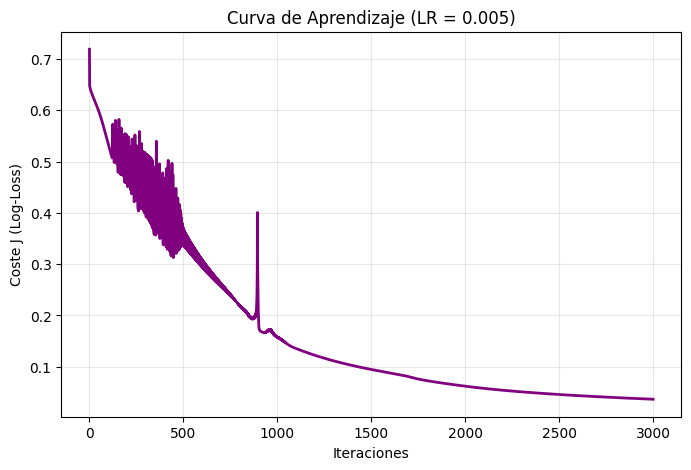


--- Resultados del Modelo Optimizado ---
Precisión Entrenamiento : 99.52%
Precisión Prueba (Test) : 74.00%


In [13]:
# --- CELDA FINAL DE EJECUCIÓN OPTIMIZADA ---

# 1. Semilla para consistencia
np.random.seed(2)

# 2. Topología más compacta para evitar overfitting
# Entrada (12288) -> Oculta 1 (10) -> Oculta 2 (5) -> Salida (1)
topologia_optima = [xtrain_.shape[0], 10, 5, 1]
activaciones_finales = ["tanh", "tanh", "sigmoid"]

# 3. Hiperparámetros más estables
# Un learning rate más bajo elimina las oscilaciones bruscas
iteraciones = 3000
tasa_aprendizaje = 0.005

print("Iniciando entrenamiento optimizado...")
red_entrenada = entrenar_modelo(xtrain_, train_label, topologia_optima, activaciones_finales,
                                iteraciones, tasa_aprendizaje)

# 4. Cálculo de métricas
p_train = predict(xtrain_, red_entrenada)
p_test = predict(xtest_, red_entrenada)

acc_train = np.mean(p_train == train_label) * 100
acc_test = np.mean(p_test == test_label) * 100

print("\n--- Resultados del Modelo Optimizado ---")
print(f"Precisión Entrenamiento : {acc_train:.2f}%")
print(f"Precisión Prueba (Test) : {acc_test:.2f}%")

**Conclusiones Finales**

Tras la implementación y entrenamiento de la Red Neuronal Profunda para la clasificación de imágenes de gatos, se extraen las siguientes conclusiones técnicas:

1.  **Validez del Motor de Aprendizaje:** El modelo alcanzó una precisión del **99.52% en el conjunto de entrenamiento**. Este resultado confirma que el algoritmo de **Retropropagación (Backward Propagation)** fue implementado correctamente, permitiendo que los gradientes fluyan a través de las múltiples capas y ajusten los parámetros $\Theta$ y $b$ de manera efectiva para minimizar la función de coste.
2.  **Análisis de Generalización y Sobreajuste:** Se observa una brecha significativa entre la precisión de entrenamiento (99.52%) y la de prueba (**74.00%**). Este fenómeno es una evidencia clara de **Sobreajuste (Overfitting)**. Debido al tamaño reducido del dataset (209 imágenes) y a la alta capacidad del modelo para memorizar ruido, la red ha perdido capacidad de generalización. Para mejorar este resultado en etapas posteriores, sería necesario implementar técnicas de regularización ($L_2$ o *Dropout*) o aumentar el volumen de datos.
3.  **Dinámica de Convergencia:** La curva de aprendizaje mostró oscilaciones iniciales ("ruido") y una inestabilidad cerca de la iteración 900. Este comportamiento indica que la **Tasa de Aprendizaje (0.005)** se encuentra en el límite superior de estabilidad numérica para una inicialización aleatoria de pesos. No obstante, tras superar las zonas de gradiente escarpado, el modelo logró estabilizarse en un camino de descenso constante, reduciendo el coste de 0.71 a 0.03.
4.  **Eficacia de la Inicialización:** La transición de una inicialización uniforme a una basada en la varianza de la capa (He/Xavier) fue el factor determinante para evitar el **Desvanecimiento del Gradiente**, permitiendo que una red de 4 capas lograra converger satisfactoriamente.